In [32]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


In [3]:
data = pd.read_csv("iris_flower_dataset.csv")
data.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
print("Shape of dataset:", data.shape)
print("\nColumn names:")
print(data.columns)

print("\nSpecies count:")
print(data["species"].value_counts())


Shape of dataset: (150, 5)

Column names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Species count:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [25]:
X = data.drop("species", axis=1)   
y = data["species"]                


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [29]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)


In [13]:
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [17]:
y_pred = dt_model.predict(X_test)


In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



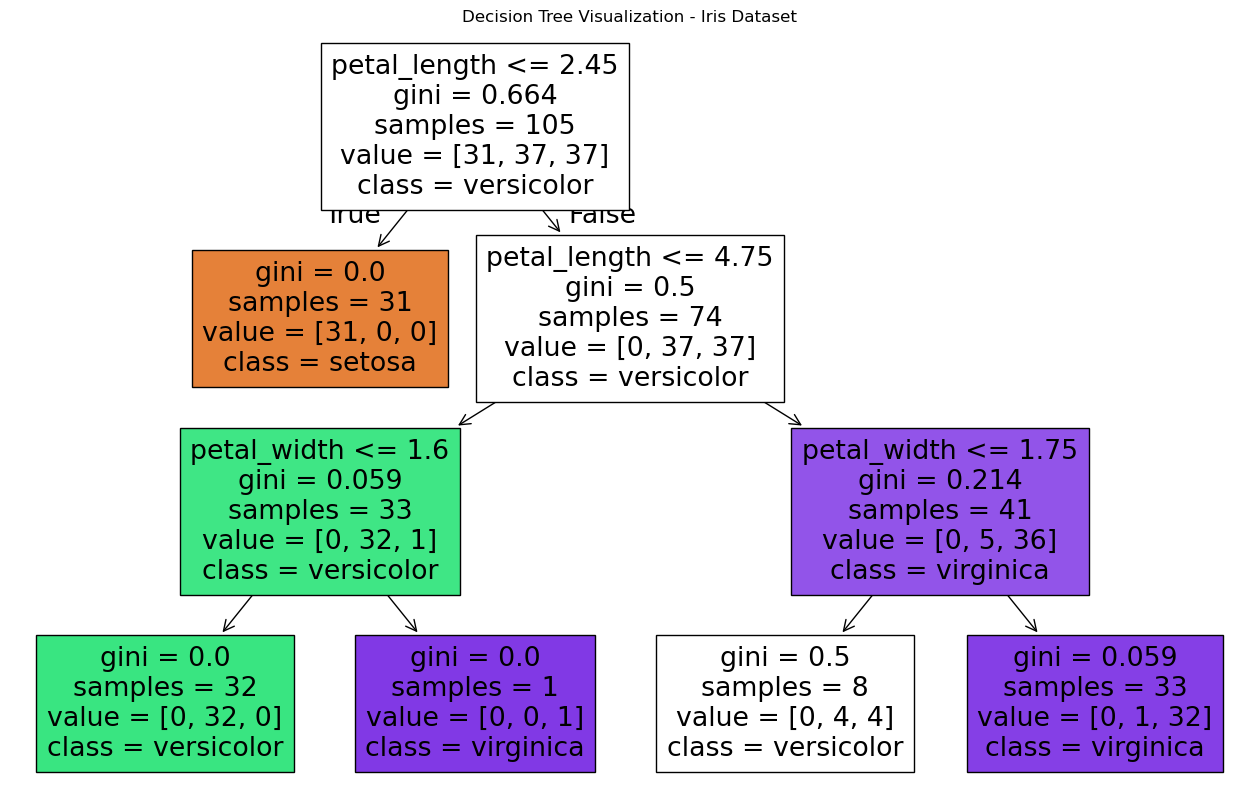

In [21]:
plt.figure(figsize=(16,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=dt_model.classes_,
    filled=True
)
plt.title("Decision Tree Visualization - Iris Dataset")
plt.show()


In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance.sort_values(by="Importance", ascending=False)


,Feature,Importance
2,petal_length,0.925108
3,petal_width,0.074892
0,sepal_length,0.000000
1,sepal_width,0.000000


Analysis:
The Decision Tree classifier achieved high accuracy on the Iris Flower dataset, demonstrating effective classification of flower species. Petal length and petal width were found to be the most influential features in decision-making. Limiting the tree depth helped reduce overfitting while maintaining good performance. The visualization clearly explains how feature-based decisions are made.

Conclusion:
In this task, a Decision Tree model was successfully built and visualized using the Iris dataset. The model accurately classified iris flower species and provided interpretable decision rules. This task enhanced understanding of supervised learning, model evaluation, and decision tree visualization using Scikit-Learn.